# InsertionSort

In [1]:
#In-place implementation of InsertionSort:
def insertion_sort(A):
  for j in range(1, len(A)):
    key = A[j]
    i = j-1
    while i>=0 and A[i]>key:
      A[i+1] = A[i]
      i -= 1
    A[i+1] = key
    
#Test of the algorithm over the array (i.e. list):
array = [43, 12, 1, 65, 32, 7]
print(f'Original array: {array}')
#insertion_sort(array)
print(f'Sorted array: {array}')

Original array: [43, 12, 1, 65, 32, 7]
Sorted array: [43, 12, 1, 65, 32, 7]


## Empirical time complexity analysis

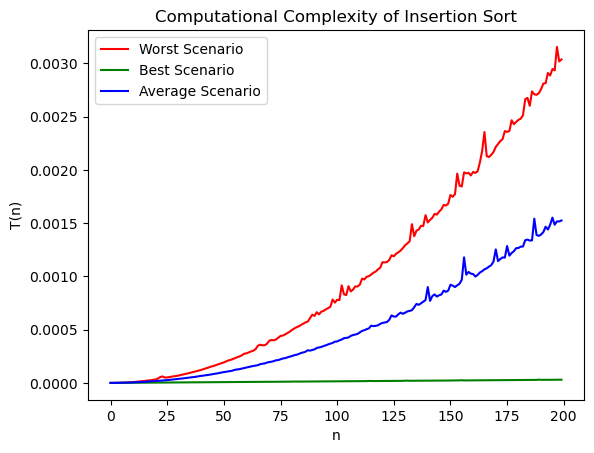

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt

def evaluate_complexity(scenario='worst', max_n = 200, extractions = 200):
  ''' This function compute the empirical time complexity of the algorithm
  InsertionSort in seconds (thus depending on the machine characteristics).

  - scenario: str,  specifies the scenario of the evaluation
  - max_n: int, maximum input dimension on which the complexity is evaluated
  - extractions: int, number of times that the evaluation for a specific input
    dimension is repeated in order to obtain an averaged and stable value
  '''
  
  computational_time = []
  for n in range(max_n):
    t = 0

    for i in range(extractions):

      A = np.random.randint(low=-10000, high=10000, size=n)

      if scenario == 'best': #already sorted array
        A.sort()
      elif scenario == 'worst': #array sorted in non-ascending order
        A.sort()
        A=A[::-1]
      elif scenario == 'average': #just a random array
        pass
      else: #if the scenario is invalid an exception is raised
        raise Exception('Invalid scenario.')

      start = time.time()
      A_sorted = insertion_sort(A)
      end = time.time()

      elapsed_time = end-start
      t += elapsed_time/extractions #averaging

    computational_time.append(t)
  return computational_time

ct_worst = evaluate_complexity() #Complexity: O(n^2)
ct_best = evaluate_complexity(scenario='best', extractions = 2000) #Complexity: O(n)
ct_average = evaluate_complexity(scenario='average')

plt.figure()
plt.plot(ct_worst, label='Worst Scenario', color = 'red')
plt.plot(ct_best, label='Best Scenario', color = 'green')
plt.plot(ct_average, label='Average Scenario', color = 'blue')
plt.title('Computational Complexity of Insertion Sort')
plt.xlabel('n')
plt.ylabel('T(n)')
plt.legend()
plt.show()

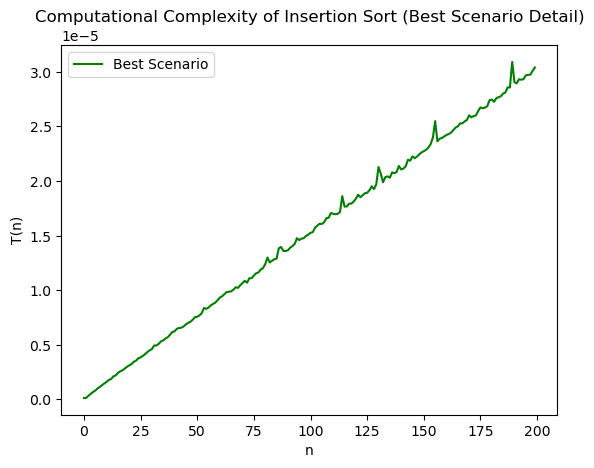

In [3]:
#if we zoom to the best case curve we can clearly see that it is a straight line
plt.figure()
plt.plot(ct_best, label='Best Scenario', color = 'green')
plt.title('Computational Complexity of Insertion Sort (Best Scenario Detail)')
plt.xlabel('n')
plt.ylabel('T(n)')
plt.legend()
plt.show()

# BinarySearch

## Recursive Approach

In [4]:
def recursive_binary_search(A, start, end, k):

  if start > end:
    return None

  #approximate the division to a lower integer
  mid = (start + end) // 2

  if A[mid] == k:
    return mid

  elif A[mid] > k:
    return recursive_binary_search(A, start, mid-1, k)

  elif A[mid] < k:
    return recursive_binary_search(A, mid+1, end, k)

array = [1, 7, 12, 32, 43, 65] # the array should be sorted

#look for number 12
number_to_find = 12
index = recursive_binary_search(array, 0, len(array)-1, number_to_find)
if index is not None:
  print(f'Element {number_to_find} found at index {index}')
else:
  print(f'Element {number_to_find} not found')

Element 12 found at index 2


## Iterative Approach

In [5]:

def iterative_binary_search(A, k):

  start_idx = 0
  end_idx = len(A)-1

  while start_idx<=end_idx:

      mid_idx = (start_idx+end_idx) // 2

      if A[mid_idx] == k:
        return mid_idx

      elif k < A[mid_idx] :
        end_idx = mid_idx - 1

      elif k > A[mid_idx] :
        start_idx = mid_idx + 1

  return None

#look for number 12
number_to_find = 12
index = iterative_binary_search(array, number_to_find)
if index is not None:
  print(f'Element {number_to_find} found at index {index}')
else:
  print(f'Element {number_to_find} not found')


Element 12 found at index 2


# MergeSort

In [6]:

def merge(A, p, q, r):
  n1 = r - p + 1
  n2 = q - r
  L = [A[p + i] for i in range(n1)] # copy A[p,r]
  R = [A[r + 1 + j] for j in range(n2)] # copy A[r+1,q]

  i, j = 0, 0

  for k in range(p, q+1):
    if i < n1:
      if j < n2:
        if L[i] <= R[j]:
          A[k] = L[i]
          i+=1

        else:
          A[k] = R[j]
          j+=1
      else:
        A[k] = L[i]
        i+=1
    else:
      A[k] = R[j]
      j+=1


def merge_sort(A, p, q):
  if p < q:
    r = (p+q)//2
    merge_sort(A, p, r)
    merge_sort(A, r+1, q)
    merge(A, p , q, r)
 
    
arr = [45, 6, 13, 9, 22, 1] 
n = len(arr)
print("Given array is")
for i in range(n):
    print("%d" % arr[i],end=" ")

merge_sort(arr, 0, n-1)

print("\n\nSorted array is")
for i in range(n):
    print("%d" % arr[i],end=" ")


Given array is
45 6 13 9 22 1 

Sorted array is
1 6 9 13 22 45 

# SelectionSort

In [7]:
def selectionSort(A):

    for j in range(len(A)-1):
        min = j

        for i in range(j + 1, len(A)):
            # select the minimum element in every iteration
            if A[i] < A[min]:
                min = i

         # swapping the elements to sort the array
        (A[j], A[min]) = (A[min], A[j])

arr = [-2, 45, 0, 11, -9,88,-97,-202,747]
selectionSort(arr)
print('The array after sorting in non-descending order by selection sort is:')
print(arr)


The array after sorting in non-descending order by selection sort is:
[-202, -97, -9, -2, 0, 11, 45, 88, 747]


# QuickSort

In [8]:
def partition(A, p, r):
  x = A[r]
  i = p - 1
  for j in range(p, r): # it's not r-1 since the range function already stops one before
    if A[j] <= x:
      i+=1
      A[j], A[i] = A[i], A[j]

  A[r], A[i+1] = A[i+1], A[r]
  return i+1


def quick_sort(A, p, r):
  if p < r:
    q = partition(A, p, r)
    quick_sort(A, p, q-1)
    quick_sort(A, q+1, r)
    
arr = [12, 11, 13, 5, 6, 7]
n = len(arr)
print("Given array is")
for i in range(n):
    print("%d" % arr[i],end=" ")

quick_sort(arr, 0, n-1)

print("\n\nSorted array is")
for i in range(n):
    print("%d" % arr[i],end=" ")

Given array is
12 11 13 5 6 7 

Sorted array is
5 6 7 11 12 13 

## Randomized QuickSort

In [9]:
import random
def rand_partition(A, p, r):
  s = random.randint(p, r) # chose pivot randomly
  A[r], A[s] = A[s], A[r] # swap the chosen pivot with teh last element
  x = A[r]
  i = p - 1
  for j in range(p, r):
    if A[j] <= x:
      i+=1
      A[j], A[i] = A[i], A[j]

  A[r], A[i+1] = A[i+1], A[r]
  return i+1

def rand_quick_sort(A, p, r):
  if p < r:
    q = rand_partition(A, p, r)
    rand_quick_sort(A, p, q-1)
    rand_quick_sort(A, q+1, r)
    
arr = [45, 6, 13, 9, 22, 1] 
n = len(arr)
print("Given array is")
for i in range(n):
    print("%d" % arr[i],end=" ")

rand_quick_sort(arr, 0, n-1)

print("\n\nSorted array is")
for i in range(n):
    print("%d" % arr[i],end=" ")






Given array is
45 6 13 9 22 1 

Sorted array is
1 6 9 13 22 45 

# BubbleSort

In [10]:
def bubble_sort(A):
    n = len(A)
    for i in range(n):
        sw = False
        for j in range(n-1): # for j in range(n-i-1) to half the time complexity
            if A[j] > A[j+1]:
                A[j], A[j+1] = A[j+1], A[j]  # Swap
                sw = True
        if not sw:  # If no two elements were swapped, the list is sorted
            break

array = [43, 12, 1, 65, 32, 7]
# optimized_bubble_sort is ordering the array in place in Python
bubble_sort(array)
print(f'Sorted array: {array}')

Sorted array: [1, 7, 12, 32, 43, 65]


# Fibonacci

Iterative Approach wit Bottom-Up Dynamic Programming. Using dynamic programming it is possible to achieve a time complexity of O(n).

In [11]:
def iterative_fib_bu(n):
    if n <= 1:
        return n

    prev2 = 0  # F(0)
    prev1 = 1  # F(1)

    for i in range(2, n + 1):
        curr = prev1 + prev2  # F(i) = F(i-1) + F(i-2)
        prev2 = prev1  # Update F(i-2)
        prev1 = curr  # Update F(i-1)

    return prev1

N_MAX = 35
import time
start_time = time.time()
for i in range(1, N_MAX + 1):
  print(iterative_fib_bu(i), end=', ')
end_time = time.time()
print(f'\nThe required time is {round(end_time-start_time,2)} seconds')

1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, 2584, 4181, 6765, 10946, 17711, 28657, 46368, 75025, 121393, 196418, 317811, 514229, 832040, 1346269, 2178309, 3524578, 5702887, 9227465, 
The required time is 0.0 seconds


Recursive Approach with Top-Down Dynamic Programming.

In [12]:
def recursive_fib_td(n, memo=None):
    # Initialize memoization dictionary if not provided
    if memo is None:
        memo = {}

    # Base cases
    if n <= 1:
        return n

    # Check if the value is already computed and stored in memo
    if n in memo:
        return memo[n]

    # Recursive call with memoization
    memo[n] = recursive_fib_td(n - 1, memo) + recursive_fib_td(n - 2, memo)

    return memo[n]

start_time = time.time()
for i in range(1, N_MAX + 1):
  print(recursive_fib_td(i), end=', ')
end_time = time.time()
print(f'\nThe required time is {round(end_time-start_time,2)} seconds')

1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, 2584, 4181, 6765, 10946, 17711, 28657, 46368, 75025, 121393, 196418, 317811, 514229, 832040, 1346269, 2178309, 3524578, 5702887, 9227465, 
The required time is 0.0 seconds
